In [1]:
!pip install optuna
!pip install betacal
!pip install matplotlib_venn
!%%time
from collections import Counter
from IPython.display import display
import lightgbm as lgb
from lightgbm import LGBMClassifier
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
from scipy.ndimage import uniform_filter1d
from scipy.stats import pearsonr
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, precision_recall_curve, auc, f1_score, average_precision_score, make_scorer, recall_score, confusion_matrix
from sklearn.model_selection import StratifiedGroupKFold, GroupShuffleSplit, train_test_split
from sklearn.preprocessing import OneHotEncoder
from optuna.pruners import MedianPruner, SuccessiveHalvingPruner
import seaborn as sns
import warnings
import os
import joblib
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import matplotlib as mpl
from functools import reduce
from matplotlib.patches import Circle, Rectangle, Ellipse
mpl.rcParams["pdf.fonttype"] = 42
mpl.rcParams["ps.fonttype"] = 42
mpl.rcParams["svg.fonttype"] = "none"
plt.rcParams["font.family"] = "Arial"

warnings.simplefilter("ignore", category=FutureWarning)
warnings.simplefilter("ignore", category=UserWarning)
optuna.logging.set_verbosity(optuna.logging.CRITICAL)

zsh:fg:1: no job control in this shell.


In [2]:
info_file = "Aves_Mam_mbio_250613.ISGcntl_reads_nologan.txt"
meta_file = "Aves_Mam_mbio_metadata_nologan_ML_250616.txt"

# Load data and filter
info = pd.read_csv(info_file, sep="\t")
info = info[info["cntl_sum"] > 10000]

# Normalization
info = info.assign(
    norm_cntl=lambda x: x['sum_salmon'] / x['cntl_sum'],
    norm_cntl_log=lambda x: np.log2(x['norm_cntl'] * (10e+5) + 1),
    norm_all=lambda x: x['sum_salmon'] / x['all_sum'],
    norm_all_log=lambda x: np.log2(x['norm_all'] * (10e+5) + 1),
)

# ISG list
isg_list = info[info["type"] == "ISG"]["hum_symbol"].unique()

# Create pivot table
info_ = info.groupby("ID")[["all_sum"]].mean()
gene_list = sorted(info["hum_symbol"].unique())
info_ = pd.concat([info_, pd.DataFrame({g: 0 for g in gene_list}, index=info_.index)], axis=1)
pivot_data = info.pivot_table(index="ID", columns="hum_symbol", values="norm_cntl_log", aggfunc="sum")
info_.update(pivot_data)

# Merge with metadata
meta_info = pd.read_csv(meta_file, sep="\t")[["ID", "Host_species", "BioProject_ID"]]
meta_info = meta_info.rename(columns={"Host_species": "h_species"})
df = pd.merge(info_, meta_info, on="ID")
display(df)

# Species filter
mbio_all = df.copy()
species_list = [x for x, c in Counter(mbio_all["h_species"]).most_common() if c > 200]

# Additional metadata
group_info = pd.read_csv(meta_file, sep="\t")
meta_info_ = group_info[["ID", "Host_species", "BioProject_ID", "order"]].rename(columns={"Host_species": "h_species"})

# Features
feature_columns = [c for c in mbio_all.columns if c not in ['BioProject_ID']]
X = mbio_all[feature_columns]

# Output directory
dir_name = "predict"
model_dir = "model"
if not os.path.exists(dir_name):
    os.makedirs(dir_name)


,ID,all_sum,ACTR2,ACTR3,ADAR,AMFR,AP2B1,ARCN1,ARPC2,ATP1A1,...,USP18,USP25,VCP,WDR1,YWHAB,ZC3HAV1,ZCCHC2,ZNFX1,h_species,BioProject_ID
0,ERR10030027,1280847.986,12.355155,13.285640,9.581239,13.055863,11.815985,12.083958,12.990153,13.412432,...,6.870538,9.484662,12.882262,12.338391,11.601064,10.111783,8.666077,10.020148,Sus_scrofa,PRJEB55168
1,ERR10125129,3811571.997,10.959960,11.277524,10.011357,12.526035,10.951070,11.637117,11.529863,15.919861,...,6.908541,9.558337,12.190075,11.549244,13.000726,0.000000,9.875906,7.962731,Gallus_gallus,PRJEB55656
2,ERR10126756,1873445.985,8.500205,7.797506,9.812926,11.531561,11.221634,9.157930,9.872471,11.896783,...,10.107160,7.119206,12.767044,10.909621,10.316812,6.382369,8.459421,11.159743,Ovis_aries,PRJEB55676
3,ERR10162446,1174608.995,13.310085,12.465041,12.278336,13.008524,13.118210,11.451809,12.556565,14.396059,...,10.031047,10.181331,13.101589,12.435257,13.770400,9.715523,14.215341,11.120289,Rattus_norvegicus,PRJEB55838
4,ERR10186694,5153060.992,10.783585,12.340436,11.584513,13.246438,15.562624,12.287267,12.086414,12.704261,...,12.774640,12.135587,13.350591,11.969607,11.750236,8.746579,11.738751,14.188654,Bos_taurus,PRJEB46995
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40641,SRR9948484,1436235.988,12.479048,12.640074,11.774386,11.284803,12.492317,12.572897,12.989155,12.950518,...,11.848283,9.550411,12.797020,12.554273,13.083568,11.207779,8.278714,13.294161,Capra_hircus,PRJNA559733
40642,SRR9951261,3483620.939,13.531020,13.890246,13.873404,11.365752,11.951490,12.237537,13.935545,12.802180,...,13.068030,12.262069,12.444267,13.198224,13.579417,12.579397,11.000464,14.704753,Bos_taurus,PRJNA559595
40643,SRR9986098,6720399.001,3.657399,9.077260,15.511446,6.262901,10.280898,12.555611,7.869816,5.924793,...,16.984952,9.214527,3.994334,6.802795,7.435842,6.939124,7.922993,18.587983,Capra_hircus,PRJNA560505
40644,SRR9986109,5943035.999,2.414468,9.628981,15.460707,6.881948,10.013341,12.438802,7.460295,6.197578,...,16.996836,8.337029,6.148088,4.686493,6.637721,7.715182,8.314771,18.606979,Capra_hircus,PRJNA560505


In [3]:
def cal_z(df, col_name):
    # z-score normalization
    df[col_name] = (df[col_name] - df[col_name].mean()) / df[col_name].std()
    return df

class CustomNormalizer(BaseEstimator, TransformerMixin):
    def __init__(self, isg_list, group_info):
        self.isg_list = isg_list
        self.group_info = group_info
        self.mean_ = None
        self.std_ = None
        self.gene_means_ = {}
        self.gene_stds_ = {}

    def transform(self, X):
        X = X.copy()
        # normalize total expression
        X['sum_all_log'] = X['all_sum'].apply(lambda x: np.log2(x + 1))
        X['sum_all_log_z'] = (X['sum_all_log'] - self.mean_) / self.std_
        X.drop(columns=['all_sum', 'sum_all_log'], inplace=True)

        # standardize each gene
        for col in self.gene_means_:
            X[col] = (X[col] - self.gene_means_[col]) / self.gene_stds_[col]

        # map species to order
        group_info_ = self.group_info[self.group_info['species'].isin(X['h_species'])]
        mapper = group_info_.drop_duplicates('species').set_index('species')['order']
        X['order'] = X['h_species'].map(mapper)

        # calculate mean ISG score
        X['mean_ISGscore'] = X[self.isg_list].mean(axis=1)
        return X


### 予測

In [5]:
# replace unknown categories
def get_train_categories_from_encoder(encoder, columns):
    categories = {}
    for col, cats in zip(columns, encoder.categories_):
        categories[col] = list(cats)
    return categories
def replace_unseen_categories(data, columns, train_categories):
    data = data.copy()
    for col in columns:
        valid = set(train_categories[col])
        data[col] = data[col].where(data[col].isin(valid), "unknown")
    return data


columns_to_process = ['h_species', "order"]   # Target columns
exclude_columns = ["ID", "h_species", "order"]  # Columns to exclude

def prediction(final_model, X_test, model, n):

  encoder = joblib.load(f'./{model_dir}/encoder_{model}_{n}.pkl')
  train_categories = get_train_categories_from_encoder(
      encoder,
      columns_to_process
  )
  X_test = replace_unseen_categories(
      X_test,
      columns=columns_to_process,
      train_categories=train_categories
  )

  # Encode categorical columns
  X_test_encoded = encoder.transform(X_test[columns_to_process])
  X_test_encoded = pd.DataFrame(X_test_encoded, index=X_test.index, columns=encoder.get_feature_names_out(columns_to_process))

  # Combine with numeric columns
  X_test_numeric = X_test.drop(columns=exclude_columns)
  X_test_final = pd.concat([X_test_numeric, X_test_encoded], axis=1)

  # Drop rows with missing values
  missing_values = X_test_final[X_test_final.isnull().any(axis=1)].index
  X_test_final = X_test_final.drop(index=missing_values)

  # Predict probabilities
  if isinstance(final_model, lgb.Booster):
        y_test_pred_prob = final_model.predict(X_test_final)
  else:
        y_test_pred_prob = final_model.predict_proba(X_test_final)[:, 1]

  # Apply threshold to get labels
  best_threshold_train = np.load(f"./{model_dir}/thresholds_{model}.npy")[n]
  y_test_pred_label = (y_test_pred_prob >= best_threshold_train).astype(int)

  return y_test_pred_label, y_test_pred_prob


In [6]:
for n in range(5):
  # Normalize
  normalizer = joblib.load(f'./{model_dir}/normalizer_{n}.pkl')
  X_test = normalizer.transform(X.copy())

  # LightGBM prediction
  if os.path.exists(f'./{model_dir}/final_model_lgb_{n}.pkl'):
    final_model_lgb = joblib.load(f'./{model_dir}/final_model_lgb_{n}.pkl')
    y_test_pred_label_lgb, y_test_pred_prob_lgb = prediction(final_model_lgb, X_test, "lgb", n)

  # Logistic Regression prediction
  if os.path.exists(f'./{model_dir}/final_model_lr_{n}.pkl'):
    final_model_lr = joblib.load(f'./{model_dir}/final_model_lr_{n}.pkl')
    y_test_pred_label_lr, y_test_pred_prob_lr = prediction(final_model_lr, X_test, "lr", n)

  # replace unknown categories
  encoder = joblib.load(f'./{model_dir}/encoder_lgb_{n}.pkl')
  train_categories = get_train_categories_from_encoder(
      encoder,
      columns_to_process
  )
  X_test = replace_unseen_categories(
      X_test,
      columns=columns_to_process,
      train_categories=train_categories
  )
  missing_values = X_test[X_test.isnull().any(axis=1)].index
  X_test_final = X_test.drop(index=missing_values)

  # Build results DataFrame
  df_long = pd.DataFrame({
        "ID": list(X_test_final["ID"]) * 2,
        "Model": ["LightGBM"] * len(X_test_final) + ["LogisticRegression"] * len(X_test_final),
        "Prediction_score": list(y_test_pred_prob_lgb) + list(y_test_pred_prob_lr),
        "Prediction_Label": list(y_test_pred_label_lgb) + list(y_test_pred_label_lr)
  })
  df_long['Prediction_Label'] = df_long['Prediction_Label'].replace({0: 'Negative', 1: 'Positive'})

  # Merge & save
  merged_df = pd.merge(meta_info_, df_long, on="ID", how="inner")
  merged_df.to_csv(f"./{dir_name}/Infection_Prediction_{n}.csv", index=False)
X_test_final

/var/folders/yp/r6xbj_r95tn65ds3frrphyp00000gn/T/ipykernel_44109/238692497.py:29: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X['order'] = X['h_species'].map(mapper)
/var/folders/yp/r6xbj_r95tn65ds3frrphyp00000gn/T/ipykernel_44109/238692497.py:32: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X['mean_ISGscore'] = X[self.isg_list].mean(axis=1)
/var/folders/yp/r6xbj_r95tn65ds3frrphyp00000gn/T/ipykernel_44109/238692497.py:29: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert`

,ID,ACTR2,ACTR3,ADAR,AMFR,AP2B1,ARCN1,ARPC2,ATP1A1,ATP5F1A,...,VCP,WDR1,YWHAB,ZC3HAV1,ZCCHC2,ZNFX1,h_species,sum_all_log_z,order,mean_ISGscore
0,ERR10030027,0.222901,0.841562,-1.041169,0.865618,-0.116854,0.265031,0.563945,0.308642,-0.617663,...,0.222846,0.380497,-0.591358,0.147537,-0.667863,-0.763148,Sus_scrofa,0.703850,Artiodactyla,-0.324064
1,ERR10125129,-0.721857,-0.442859,-0.784521,0.619964,-0.767458,-0.133612,-0.517794,1.163243,-0.097581,...,-0.119722,-0.004964,0.350948,-2.464195,-0.168248,-1.737801,Gallus_gallus,1.633379,Galliformes,-0.545953
2,ERR10126756,-2.387483,-2.668729,-0.902923,0.158877,-0.563935,-2.345386,-1.745540,-0.207933,1.041483,...,0.165824,-0.317390,-1.455966,-0.815718,-0.753204,-0.223291,Ovis_aries,1.027971,Artiodactyla,-0.465539
3,ERR10162446,0.869533,0.316695,0.568163,0.843669,0.862704,-0.298933,0.242756,0.643890,0.324984,...,0.331392,0.427812,0.869122,0.045189,1.623778,-0.241981,Rattus_norvegicus,0.630045,Rodentia,0.036303
4,ERR10186694,-0.841290,0.236995,0.154166,0.953978,2.701437,0.446410,-0.105517,0.067278,-0.112841,...,0.454626,0.200363,-0.490930,-0.205076,0.601038,1.211585,Bos_taurus,1.890412,Artiodactyla,0.295444
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40641,SRR9948484,0.306796,0.428648,0.267461,0.044467,0.391896,0.701231,0.563206,0.151209,-0.520183,...,0.180659,0.485946,0.406721,0.430618,-0.827829,0.787840,Capra_hircus,0.801449,Artiodactyla,0.047287
40642,SRR9951261,1.019140,1.228277,1.519924,0.081999,-0.014924,0.402045,1.264264,0.100651,-0.138324,...,0.006079,0.800486,0.740545,0.784888,0.296153,1.456075,Bos_taurus,1.556692,Artiodactyla,1.112145
40643,SRR9986098,-5.666795,-1.850179,2.497328,-2.283935,-1.271574,0.685810,-3.229047,-2.243352,-5.953610,...,-4.175854,-2.323383,-3.395545,-0.671916,-0.974729,3.295665,Capra_hircus,2.116765,Artiodactyla,0.283585
40644,SRR9986109,-6.508447,-1.497291,2.467052,-1.996914,-1.472835,0.581601,-3.532408,-2.150380,-4.439913,...,-3.109946,-3.357098,-3.932871,-0.471471,-0.812939,3.304664,Capra_hircus,2.011985,Artiodactyla,0.251642


# **アンサンブル(スタッキング)**

In [8]:
def train_stacking_model(X_test, n):
    # Create meta features for each fold
    X_test_meta = pd.read_csv(f"./{dir_name}/Infection_Prediction_{n}.csv").pivot(index="ID", columns="Model", values="Prediction_score").fillna(0)
    for model in ["LightGBM", "LogisticRegression"]:
        X_test_meta = cal_z(X_test_meta.astype(float), model)

    # Preprocess test data
    encoder = joblib.load(f'./{model_dir}/encoder_meta_{n}.pkl')
    train_categories = get_train_categories_from_encoder(
        encoder,
        columns_to_process
    )
    X_test = replace_unseen_categories(
        X_test,
        columns=columns_to_process,
        train_categories=train_categories
    )
    missing_values = X_test[X_test.isnull().any(axis=1)].index
    X_test_final = X_test.drop(index=missing_values)

    # Merge with additional features
    X_test_meta = X_test_meta.merge(X_test_final[['ID', 'h_species', 'order']], on='ID', how='left')

    # Run prediction with trained meta model
    if os.path.exists(f'./{model_dir}/final_model_meta_{n}.pkl'):
      final_model_meta = joblib.load(f'./{model_dir}/final_model_meta_{n}.pkl')
      y_test_pred_label_meta, y_test_pred_prob_meta = prediction(final_model_meta, X_test_meta, "meta", n)

    return final_model_meta, y_test_pred_label_meta, y_test_pred_prob_meta, X_test_meta


# Save results for each fold
for n in range(5):
    normalizer = joblib.load(f'./{model_dir}/normalizer_{n}.pkl')
    X_test = normalizer.transform(X.copy())
    meta_model, y_test_pred_meta, y_test_pred_prob_meta, X_test_meta = train_stacking_model(X_test, n)

    df_long = pd.DataFrame({
        "ID": X_test_meta["ID"],
        "Model": "Stacking",
        "Prediction_score": y_test_pred_prob_meta,
        "Prediction_Label": y_test_pred_meta,
    })
    df_long["Prediction_Label"] = df_long["Prediction_Label"].replace({0: "Negative", 1: "Positive"})

    merged_df = pd.merge(meta_info_, df_long, on="ID", how="inner").sort_values(by="ID")
    merged_df.to_csv(f"./{dir_name}/Infection_Prediction_Stacking_{n}_external.csv", index=False)


# Combine all folds and create final label by majority vote
all_dfs = []
for n in range(5):
    normalizer = joblib.load(f'./{model_dir}/normalizer_{n}.pkl')
    X_test = normalizer.transform(X.copy())
    meta_model, y_test_pred_meta, y_test_pred_prob_meta, X_test_meta = train_stacking_model(X_test, n)

    df_long = pd.DataFrame({
        "ID": X_test_meta["ID"],
        f"Prediction_score_fold{n}": y_test_pred_prob_meta,
        f"Prediction_Label_fold{n}": y_test_pred_meta,
    })
    df_long[f"Prediction_Label_fold{n}"] = df_long[f"Prediction_Label_fold{n}"].replace({0: "Negative", 1: "Positive"})

    all_dfs.append(df_long)

merged_df = meta_info_.copy()
for df in all_dfs:
    merged_df = pd.merge(merged_df, df, on="ID", how="inner")

label_cols = [f"Prediction_score_fold{n}" for n in range(5)]
merged_df["Final_Prediction_score(mean)"] = merged_df[label_cols].mean(axis=1)
label_cols = [f"Prediction_Label_fold{n}" for n in range(5)]
merged_df["Final_Prediction_Label"] = merged_df[label_cols].mode(axis=1)[0]

# Save final results
merged_df = merged_df.sort_values(by="ID")
merged_df.to_csv(f"./{dir_name}/Infection_Prediction_Stacking_all.csv", index=False)
merged_df.to_csv(f"./{dir_name}/Infection_Prediction_Stacking_all.txt", sep="\t", index=False)

final_df = merged_df[["ID", "Final_Prediction_score(mean)", "Final_Prediction_Label"]]
final_df = final_df.rename(columns={
    "Final_Prediction_score(mean)": "Prediction_score(mean)",
    "Final_Prediction_Label": "Prediction_Label"
})
final_df.to_csv(f"./{dir_name}/Infection_Prediction_Stacking_final.csv", index=False)
final_df.to_csv(f"./{dir_name}/Infection_Prediction_Stacking_final.txt", sep="\t", index=False)
final_df[final_df["Prediction_Label"]=="Positive"]


/var/folders/yp/r6xbj_r95tn65ds3frrphyp00000gn/T/ipykernel_44109/238692497.py:29: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X['order'] = X['h_species'].map(mapper)
/var/folders/yp/r6xbj_r95tn65ds3frrphyp00000gn/T/ipykernel_44109/238692497.py:32: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X['mean_ISGscore'] = X[self.isg_list].mean(axis=1)
/var/folders/yp/r6xbj_r95tn65ds3frrphyp00000gn/T/ipykernel_44109/238692497.py:29: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert`

,ID,Prediction_score(mean),Prediction_Label
28507,ERR11219020,0.968094,Positive
39123,ERR11219054,0.968094,Positive
1097,ERR11630589,0.839399,Positive
1173,ERR11630665,0.964804,Positive
1193,ERR11630685,0.963236,Positive
...,...,...,...
29,SRR8996661,0.968094,Positive
39947,SRR8996962,0.894333,Positive
35873,SRR9669938,0.968094,Positive
35967,SRR9936781,0.862607,Positive


a: 962, b: 38, c: 1771, d: 1070
True Positive: 1070
False Positive: 1771
True Negative: 36368.409999999996
False Negative: 1436.59
Confusion Matrix:
[[36368.  1771.]
 [ 1437.  1070.]]
40646.0
Precision: 0.3766
Recall: 0.4268
F1-score: 0.4001
standard error of True Negative: 225.53456502511952
standard error of False Negative: 225.53456502511978
standard error of F1score: 0.030949427250736093
F1score is about 0.4311 to 0.3692
0.06989617674555922


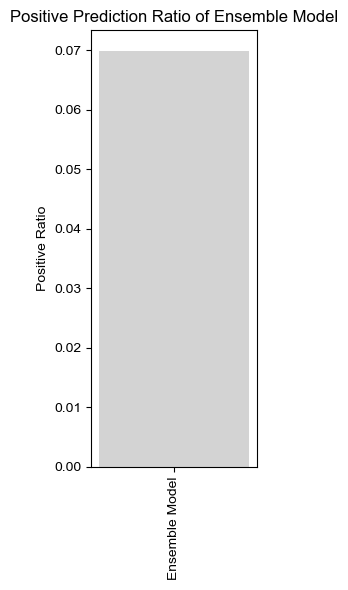

Recall: 0.4268049461507778
Recall error: 0.03839619779843851


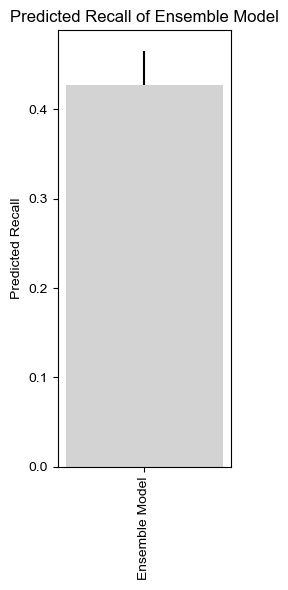

In [10]:
# create Confusion Matrix
pred_file = f"./{dir_name}/Infection_Prediction_Stacking_final.txt"
pred_info = pd.read_csv(pred_file, sep = "\t")
pred_info["Prediction_Label"] = pred_info["Prediction_Label"].map({"Positive": 1, "Negative": 0})

merged_df = pd.merge(pred_info, exp_info, on="ID", how="inner")

conf_matrix = confusion_matrix(merged_df["Infection"], merged_df["Prediction_Label"])
only_in_df1 = set(pred_info[pred_info["Prediction_Label"]==1]['ID']) - set(merged_df[merged_df["Prediction_Label"]==1]['ID'])

a = conf_matrix[0][0]
b = conf_matrix[1][0]
c = conf_matrix[0][1]
d = conf_matrix[1][1]
print(f"a: {a}, b: {b}, c: {c}, d: {d}")

ALL = 40646
print(f"True Positive: {d}")
print(f"False Positive: {c}")
print(f"True Negative: {(ALL-(c+d))*(a/(a+b))}")
print(f"False Negative: {(ALL-(c+d))*(b/(a+b))}")
Confusion_Matrix = np.zeros((2, 2))
Confusion_Matrix[0][0] = round((ALL-(c+d))*(a/(a+b)))
Confusion_Matrix[1][0] = round((ALL-(c+d))*(b/(a+b)))
Confusion_Matrix[0][1] = c
Confusion_Matrix[1][1] = d
print("Confusion Matrix:")
print(Confusion_Matrix)
print(sum(sum(Confusion_Matrix)))

a_ = Confusion_Matrix[0][0]  # TN
b_ = Confusion_Matrix[1][0]  # FN
c_ = Confusion_Matrix[0][1]  # FP
d_ = Confusion_Matrix[1][1]  # TP

# Positive Ratio, Precision, Recall, F1
pos_rate = (c_ + d_)/(a_ + b_ + c_ + d_)
precision = d_ / (d_ + c_) if (d_ + c_) != 0 else 0
recall = d_ / (d_ + b_) if (d_ + b_) != 0 else 0
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) != 0 else 0

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

def se(k):
    N = ALL-(c+d)
    n = a+b
    K = N*k/n
    return (K*(N-K)/n*(N-n)/(N-1))**0.5
    

print(f"standard error of True Negative: {se(a)}")
print(f"standard error of False Negative: {se(b)}")

def dF1(matrix):
    return -2*matrix[1][1]/(2*matrix[1][1] + matrix[0][1] + matrix[1][0])**2

F1_error = abs(dF1(conf_matrix) * se(b))
print(f"standard error of F1score: {F1_error}")
print(f"F1score is about {f1+F1_error:.4f} to {f1-F1_error:.4f}")

# Positive Ratio
print(pos_rate)
plt.figure(figsize=(2.5, 6))
plt.bar([0], [pos_rate], color="lightgray")
plt.xticks([0], ["Ensemble Model"], rotation=90)
plt.ylabel("Positive Ratio")
plt.title("Positive Prediction Ratio of Ensemble Model")
plt.tight_layout()
plt.savefig(f"./{dir_name}/Positive_Prediction_Ratio_of_EnsembleModel.pdf", bbox_inches='tight')
plt.show()

# Recall
def dRecall(FN, TP):
    return -TP/((TP+FN)**2)
recall_error = abs(dRecall(b_, d_) * se(b))
print(f"Recall: {recall}")
print(f"Recall error: {recall_error}")
plt.figure(figsize=(2.5, 6))
plt.bar([0], [recall], yerr=[[0],[recall_error]], color="lightgray")
plt.xticks([0], ["Ensemble Model"], rotation=90)
plt.ylabel("Predicted Recall")
plt.title("Predicted Recall of Ensemble Model")
plt.tight_layout()
plt.savefig(f"./{dir_name}/Predicted_Recall_of_EnsembleModel.pdf", bbox_inches='tight')
plt.show()

save_path = f"./{dir_name}/calculated_results.txt"

with open(save_path, "w") as f:
    f.write("===== Confusion Matrix =====\n")
    f.write(f"TN: {a_}\n")
    f.write(f"FN: {b_}\n")
    f.write(f"FP: {c_}\n")
    f.write(f"TP: {d_}\n\n")

    f.write("===== Performance Metrics =====\n")
    f.write(f"Positive Ratio: {pos_rate}\n")
    f.write(f"Precision: {precision}\n")
    f.write(f"Recall: {recall}\n")
    f.write(f"F1-score: {f1}\n\n")

    f.write("===== Standard Errors =====\n")
    f.write(f"SE(TN): {se(a)}\n")
    f.write(f"SE(FN): {se(b)}\n")
    f.write(f"SE(F1score): {F1_error}\n")
    f.write(f"F1score range: {f1 - F1_error} 〜 {f1 + F1_error}\n")
    f.write(f"Recall Error: {recall_error}\n")


In [13]:
def calc_F1(conf_matrix):
    a = conf_matrix[0][0]
    b = conf_matrix[1][0]
    c = conf_matrix[0][1]
    d = conf_matrix[1][1]
    print(f"a: {a}, b: {b}, c: {c}, d: {d}")
    ALL = 40646
    Confusion_Matrix = np.zeros((2, 2))
    Confusion_Matrix[0][0] = round((ALL-(c+d))*(a/(a+b)))
    Confusion_Matrix[1][0] = round((ALL-(c+d))*(b/(a+b)))
    Confusion_Matrix[0][1] = c
    Confusion_Matrix[1][1] = d
    print("Confusion Matrix:")
    print(Confusion_Matrix)
    print(sum(sum(Confusion_Matrix)))
    a_ = Confusion_Matrix[0][0]  # TN
    b_ = Confusion_Matrix[1][0]  # FN
    c_ = Confusion_Matrix[0][1]  # FP
    d_ = Confusion_Matrix[1][1]  # TP
    # Precision, Recall, F1
    precision = d_ / (d_ + c_) if (d_ + c_) != 0 else 0
    recall = d_ / (d_ + b_) if (d_ + b_) != 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) != 0 else 0
    print(f"F1-score: {f1:.4f}")
    F1_error = abs(dF1(Confusion_Matrix) * se(b))
    recall_error = abs(dRecall(b_, d_) * se(b))
    l = [0.35910940866650704, 0.3049514113836187, 0.4777777777777778, 0.35846153846153844, 0.2941622441243366,0]
    return [f1, F1_error, recall, recall_error, l[n]]


Confusion Matrix(0):
[[1168 1565]
 [ 104 1004]]
a: 1168, b: 104, c: 1565, d: 1004
Confusion Matrix:
[[34964.  1565.]
 [ 3113.  1004.]]
40646.0
F1-score: 0.3003
Confusion Matrix(1):
[[1250 1483]
 [ 101 1007]]
a: 1250, b: 101, c: 1483, d: 1007
Confusion Matrix:
[[35303.  1483.]
 [ 2853.  1007.]]
40646.0
F1-score: 0.3172
Confusion Matrix(2):
[[1213 1520]
 [ 107 1001]]
a: 1213, b: 107, c: 1520, d: 1001
Confusion Matrix:
[[35035.  1520.]
 [ 3090.  1001.]]
40646.0
F1-score: 0.3028
Confusion Matrix(3):
[[1246 1487]
 [ 108 1000]]
a: 1246, b: 108, c: 1487, d: 1000
Confusion Matrix:
[[35115.  1487.]
 [ 3044.  1000.]]
40646.0
F1-score: 0.3062
Confusion Matrix(4):
[[1199 1534]
 [ 100 1008]]
a: 1199, b: 100, c: 1534, d: 1008
Confusion Matrix:
[[35171.  1534.]
 [ 2933.  1008.]]
40646.0
F1-score: 0.3110
a: 962, b: 38, c: 1771, d: 1070
Confusion Matrix:
[[36368.  1771.]
 [ 1437.  1070.]]
40646.0
F1-score: 0.4001
0.3588924760827557


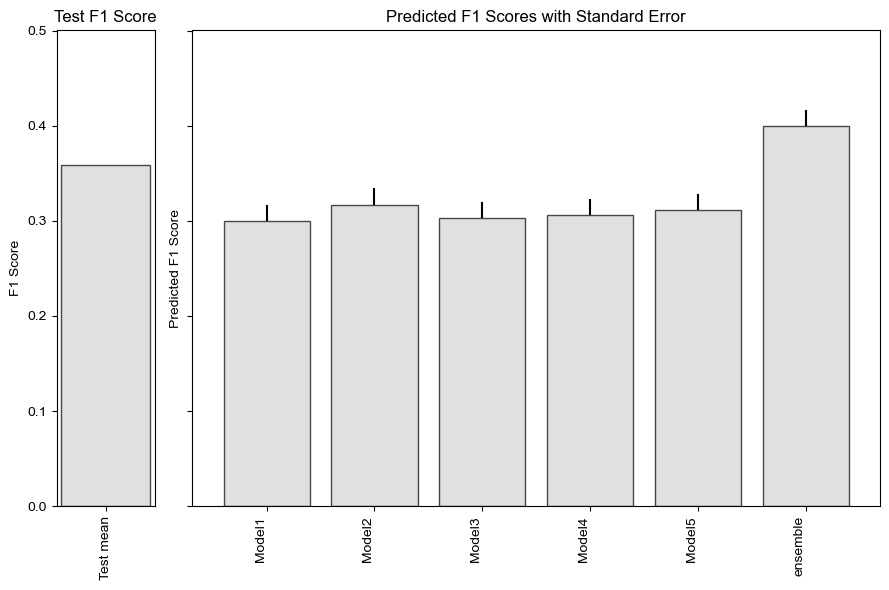

[0.30032904576727487, 0.3171653543307087, 0.30278281911675736, 0.3062318174858368, 0.3109671448403517, 0.400149588631264]
[0.24386689336895798, 0.26088082901554405, 0.24468345147885603, 0.24727992087042533, 0.2557726465364121, 0.4268049461507778]
[0.02132929149266649, 0.024023106695374684, 0.02180853602240292, 0.022387509712974103, 0.022966916596718782, 0.03839619779843851]


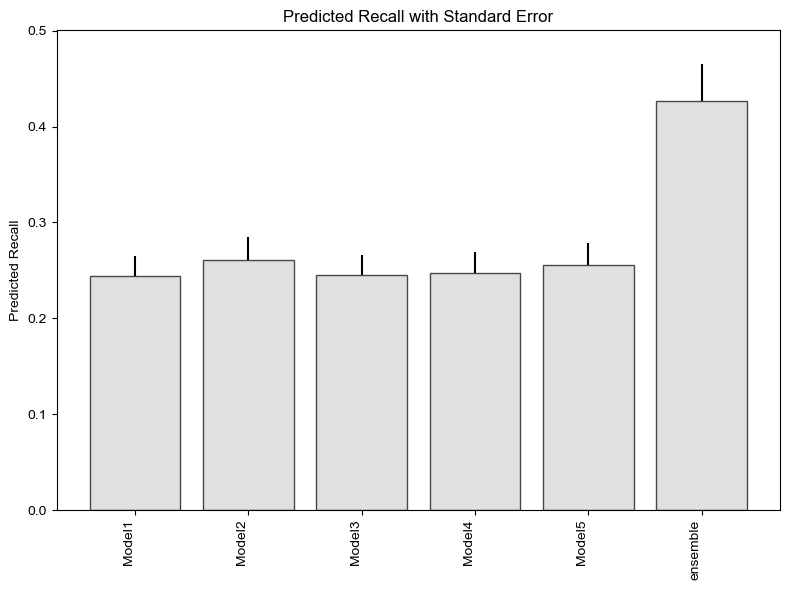

In [19]:
dir_name = "predict"

# Load experience data
exp_file = "Aves_Mam_mbio_metadata_ISG_nologan3942_ML_251110.txt"
exp_info = pd.read_csv(exp_file, sep = "\t")
exp_info = exp_info[["ID", "ISG_level"]]
exp_info = exp_info.rename(columns={"ISG_level": "Infection"})
replace_dict = {'both': 1, 'high': 1, 'low': 0, 'Negative': 0}
exp_info['Infection'] = exp_info['Infection'].replace(replace_dict)
id_file = "external_negative_1000_samples_ID_251125.txt"
id_info = pd.read_csv(id_file, sep = "\t")
neg_info = exp_info[exp_info["ID"].isin(id_info["ID"])]
pred_file = f"./{dir_name}/Infection_Prediction_Stacking_final.txt"
pred_info = pd.read_csv(pred_file, sep = "\t")
pred_info["Prediction_Label"] = pred_info["Prediction_Label"].map({"Positive": 1, "Negative": 0})
id_list = pred_info.loc[pred_info["Prediction_Label"] == 1, "ID"]
pos_info = exp_info[exp_info["ID"].isin(id_list)]
exp_info = pd.concat([pos_info, neg_info], axis=0)

prauc = []
f1score = []
Confusion_Matrix = np.zeros((2, 2))
f1_list = []
for n in range(5):
    pred_df = pd.read_csv(f"./{dir_name}/Infection_Prediction_Stacking_{n}_external.csv")
    merged_df = pd.merge(pred_df, exp_info, on="ID", how="inner")
    y_test = merged_df["Infection"]
    y_test_pred_label = merged_df["Prediction_Label"]
    label_mapping = {'Positive': 1, 'Negative': 0}
    y_test_pred_label = y_test_pred_label.map(label_mapping)
    y_test_pred_prob = merged_df["Prediction_score"]

    F1_score = f1_score(y_test, y_test_pred_label.astype(int))
    conf_matrix = confusion_matrix(y_test, y_test_pred_label)
    print(f"Confusion Matrix({n}):")
    print(conf_matrix)
    precision, recall, _ = precision_recall_curve(y_test, y_test_pred_prob)
    PRAUC = auc(recall, precision)
    prauc.append(PRAUC)
    f1score.append(F1_score)
    Confusion_Matrix += conf_matrix

    f1_list.append(calc_F1(conf_matrix))

pred_file = f"./{dir_name}/Infection_Prediction_Stacking_final.txt"
pred_info = pd.read_csv(pred_file, sep = "\t")
pred_info["Prediction_Label"] = pred_info["Prediction_Label"].map({"Positive": 1, "Negative": 0})
merged_df = pd.merge(pred_info, exp_info, on="ID", how="inner")

conf_matrix = confusion_matrix(merged_df["Infection"], merged_df["Prediction_Label"])
f1_list.append(calc_F1(conf_matrix))

f1_scores = [x[0] for x in f1_list]
std_err = [x[1] for x in f1_list]

# test score of learning stage
l = [0.35910940866650704, 0.3049514113836187, 0.4777777777777778, 0.35846153846153844, 0.2941622441243366]
test_mean = sum(l)/len(l)
print(test_mean)

x = np.arange(len(f1_scores))

max_val = max([a + b for a, b in zip(f1_scores, std_err)] + [test_mean])
ylim_top = max(0.01, max_val * 1.2)

fig, axes = plt.subplots(
    1, 2, figsize=(9, 6),
    gridspec_kw={'width_ratios': [1, 7]},
    sharey=True
)
model_list = ["Model1", "Model2", "Model3", "Model4", "Model5", "ensemble"]

axes[1].bar(
    x, f1_scores, yerr=[np.zeros(len(std_err)), std_err], capsize=0, alpha=0.7, 
    edgecolor="black", color="lightgray"
)
axes[1].set_xticks(x)
axes[1].set_xticklabels(model_list, rotation=90, ha="right")
axes[1].set_ylabel("Predicted F1 Score")
axes[1].set_title("Predicted F1 Scores with Standard Error")
axes[1].set_ylim(0, ylim_top)

axes[0].bar(
    [0], [test_mean], capsize=5, alpha=0.7, edgecolor="black", color="lightgray", width=0.5
)
axes[0].set_xticks([0])
axes[0].set_xticklabels(["Test mean"], rotation=90)
axes[0].set_ylabel("F1 Score")
axes[0].set_title("Test F1 Score")
axes[0].set_ylim(0, ylim_top)


plt.savefig(f"./{dir_name}/F1score_bar.pdf", bbox_inches='tight')
plt.tight_layout()
plt.show()

recalls = [x[2] for x in f1_list]
recall_std_err = [x[3] for x in f1_list]
print(f1_scores)
print(recalls)
print(recall_std_err)
fig, ax = plt.subplots(figsize=(8, 6))

ax.bar(
    x,
    recalls,
    yerr=[np.zeros(len(recall_std_err)), recall_std_err],
    capsize=0,
    alpha=0.7,
    edgecolor="black",
    color="lightgray"
)

ax.set_xticks(x)
ax.set_xticklabels(model_list, rotation=90, ha="right")
ax.set_ylabel("Predicted Recall")
ax.set_title("Predicted Recall with Standard Error")
ax.set_ylim(0, ylim_top)

plt.tight_layout()
plt.savefig(f"./{dir_name}/Recall_bar.pdf", bbox_inches='tight')
plt.show()


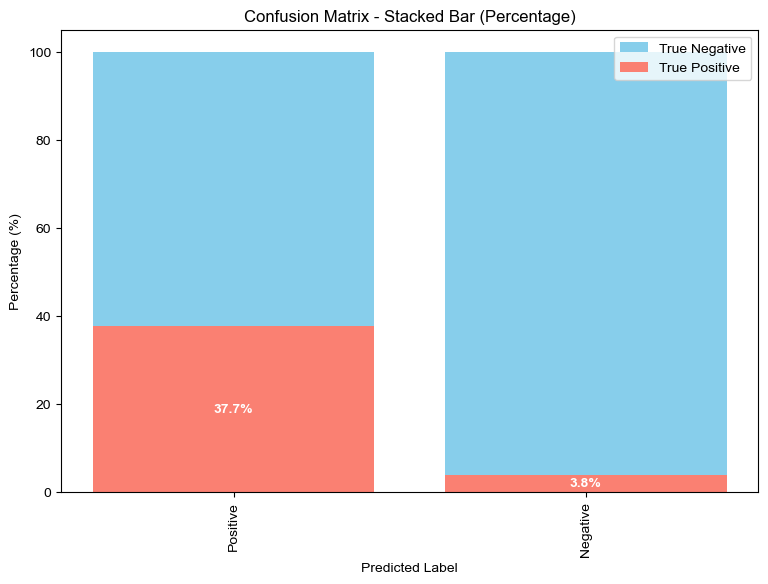

In [20]:
ALL = 40646

Confusion_Matrix = np.zeros((2, 2))
Confusion_Matrix[0][0] = d
Confusion_Matrix[1][0] = c
Confusion_Matrix[0][1] = round((ALL-(c+d))*(b/(a+b)))
Confusion_Matrix[1][1] = round((ALL-(c+d))*(a/(a+b)))

labels = ['Positive', 'Negative']  # True Label
pred_labels = ['Positive', 'Negative']  # Predicted Label

cm_df = pd.DataFrame(Confusion_Matrix, index=labels, columns=pred_labels)

cm_percent = cm_df / cm_df.sum(axis=0) * 100

fig, ax = plt.subplots(figsize=(9, 6))

ax.bar(pred_labels, cm_percent.loc['Negative'], bottom=cm_percent.loc['Positive'], label='True Negative', color='skyblue')
ax.bar(pred_labels, cm_percent.loc['Positive'], label='True Positive', color='salmon')

ax.set_xlabel('Predicted Label')
ax.set_ylabel('Percentage (%)')
ax.set_title('Confusion Matrix - Stacked Bar (Percentage)')
ax.legend()

for i, label in enumerate(pred_labels):
    tp_percent = cm_percent.loc['Positive', label]
    ax.text(i, tp_percent/2, f"{tp_percent:.1f}%", ha='center', va='center', color='white', fontweight='bold')
plt.xticks(rotation=90)
plt.savefig(f"./{dir_name}/stacked_bar.pdf", bbox_inches='tight')
plt.show()


In [41]:
all_merged_dfs = []
fold_dfs = []

for n in range(5):
    df = pd.read_csv(f"./{dir_name}/Infection_Prediction_Stacking_{n}_external.csv")
    
    df = pd.merge(df, exp_info, on="ID", how="left")

    df["experiment"] = df["Infection"].notna()

    df["Infection"] = df["Infection"].fillna("unknown")

    normalizer = joblib.load(f'./{model_dir}/normalizer_{n}.pkl')
    X_test = normalizer.transform(X.copy())
    X_test_ = X_test[["ID", "mean_ISGscore"]].copy()

    merged_df = pd.merge(X_test_, df, on='ID', how='inner')

    display(merged_df)
    all_merged_dfs.append(merged_df)


for i, df in enumerate(all_merged_dfs):
    tmp = df[["ID", "experiment", "Infection", "mean_ISGscore", "Prediction_score"]].copy()

    tmp = tmp.rename(columns={
        "mean_ISGscore": f"mean_ISGscore_fold{i}",
        "Prediction_score": f"Pred_prob_fold{i}"
    })

    tmp[f"Pred_label_fold{i}"] = (tmp[f"Pred_prob_fold{i}"] >= 0.5).astype(int)

    fold_dfs.append(tmp)

merged_pred = reduce(
    lambda l, r: pd.merge(l, r, on=["ID", "experiment", "Infection"], how="inner"),
    fold_dfs
)

prob_cols = [c for c in merged_pred.columns if c.startswith("Pred_prob_fold")]

merged_pred["Pred_prob_mean"] = merged_pred[prob_cols].mean(axis=1)

label_cols = [c for c in merged_pred.columns if c.startswith("Pred_label_fold")]

merged_pred["Pred_label_majority"] = (
    merged_pred[label_cols].sum(axis=1) >= (len(label_cols) / 2)
).astype(int)

replace_dict = {0: "Negative", 1: "Positive"}
merged_pred["Infection"] = merged_pred["Infection"].replace(replace_dict)
label_cols = [c for c in merged_pred.columns if c.startswith("Pred_label_fold")]

for col in label_cols:
    merged_pred[col] = merged_pred[col].replace(replace_dict)
merged_pred["Pred_label_majority"] = (
    merged_pred["Pred_label_majority"].replace(replace_dict)
)

merged_pred[merged_pred["Infection"]=="Positive"]

/var/folders/yp/r6xbj_r95tn65ds3frrphyp00000gn/T/ipykernel_44109/238692497.py:29: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X['order'] = X['h_species'].map(mapper)
/var/folders/yp/r6xbj_r95tn65ds3frrphyp00000gn/T/ipykernel_44109/238692497.py:32: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X['mean_ISGscore'] = X[self.isg_list].mean(axis=1)


,ID,mean_ISGscore,h_species,BioProject_ID,order,Model,Prediction_score,Prediction_Label,Infection,experiment
0,ERR10030027,-0.311481,Sus_scrofa,PRJEB55168,Artiodactyla,Stacking,0.717143,Negative,unknown,False
1,ERR10125129,-0.530760,Gallus_gallus,PRJEB55656,Galliformes,Stacking,0.035136,Negative,unknown,False
2,ERR10126756,-0.452209,Ovis_aries,PRJEB55676,Artiodactyla,Stacking,0.035136,Negative,unknown,False
3,ERR10162446,0.042686,Rattus_norvegicus,PRJEB55838,Rodentia,Stacking,0.037266,Negative,unknown,False
4,ERR10186694,0.303529,Bos_taurus,PRJEB46995,Artiodactyla,Stacking,0.035136,Negative,unknown,False
...,...,...,...,...,...,...,...,...,...,...
40641,SRR9948484,0.057309,Capra_hircus,PRJNA559733,Artiodactyla,Stacking,0.035136,Negative,unknown,False
40642,SRR9951261,1.098065,Bos_taurus,PRJNA559595,Artiodactyla,Stacking,0.736248,Negative,0.0,True
40643,SRR9986098,0.291533,Capra_hircus,PRJNA560505,Artiodactyla,Stacking,0.035136,Negative,unknown,False
40644,SRR9986109,0.259571,Capra_hircus,PRJNA560505,Artiodactyla,Stacking,0.035136,Negative,unknown,False


/var/folders/yp/r6xbj_r95tn65ds3frrphyp00000gn/T/ipykernel_44109/238692497.py:29: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X['order'] = X['h_species'].map(mapper)
/var/folders/yp/r6xbj_r95tn65ds3frrphyp00000gn/T/ipykernel_44109/238692497.py:32: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X['mean_ISGscore'] = X[self.isg_list].mean(axis=1)


,ID,mean_ISGscore,h_species,BioProject_ID,order,Model,Prediction_score,Prediction_Label,Infection,experiment
0,ERR10030027,-0.317045,Sus_scrofa,PRJEB55168,Artiodactyla,Stacking,0.677593,Negative,unknown,False
1,ERR10125129,-0.530731,Gallus_gallus,PRJEB55656,Galliformes,Stacking,0.061597,Negative,unknown,False
2,ERR10126756,-0.454592,Ovis_aries,PRJEB55676,Artiodactyla,Stacking,0.061845,Negative,unknown,False
3,ERR10162446,0.034098,Rattus_norvegicus,PRJEB55838,Rodentia,Stacking,0.254515,Negative,unknown,False
4,ERR10186694,0.290019,Bos_taurus,PRJEB46995,Artiodactyla,Stacking,0.070918,Negative,unknown,False
...,...,...,...,...,...,...,...,...,...,...
40641,SRR9948484,0.045431,Capra_hircus,PRJNA559733,Artiodactyla,Stacking,0.061597,Negative,unknown,False
40642,SRR9951261,1.077642,Bos_taurus,PRJNA559595,Artiodactyla,Stacking,0.836535,Negative,0.0,True
40643,SRR9986098,0.280112,Capra_hircus,PRJNA560505,Artiodactyla,Stacking,0.066962,Negative,unknown,False
40644,SRR9986109,0.249049,Capra_hircus,PRJNA560505,Artiodactyla,Stacking,0.062828,Negative,unknown,False


/var/folders/yp/r6xbj_r95tn65ds3frrphyp00000gn/T/ipykernel_44109/238692497.py:29: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X['order'] = X['h_species'].map(mapper)
/var/folders/yp/r6xbj_r95tn65ds3frrphyp00000gn/T/ipykernel_44109/238692497.py:32: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X['mean_ISGscore'] = X[self.isg_list].mean(axis=1)


...

/var/folders/yp/r6xbj_r95tn65ds3frrphyp00000gn/T/ipykernel_44109/238692497.py:29: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X['order'] = X['h_species'].map(mapper)
/var/folders/yp/r6xbj_r95tn65ds3frrphyp00000gn/T/ipykernel_44109/238692497.py:32: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X['mean_ISGscore'] = X[self.isg_list].mean(axis=1)


,ID,mean_ISGscore,h_species,BioProject_ID,order,Model,Prediction_score,Prediction_Label,Infection,experiment
0,ERR10030027,-0.312997,Sus_scrofa,PRJEB55168,Artiodactyla,Stacking,0.293163,Negative,unknown,False
1,ERR10125129,-0.538711,Gallus_gallus,PRJEB55656,Galliformes,Stacking,0.040517,Negative,unknown,False
2,ERR10126756,-0.469246,Ovis_aries,PRJEB55676,Artiodactyla,Stacking,0.040517,Negative,unknown,False
3,ERR10162446,0.058394,Rattus_norvegicus,PRJEB55838,Rodentia,Stacking,0.390436,Negative,unknown,False
4,ERR10186694,0.323268,Bos_taurus,PRJEB46995,Artiodactyla,Stacking,0.279891,Negative,unknown,False
...,...,...,...,...,...,...,...,...,...,...
40641,SRR9948484,0.061494,Capra_hircus,PRJNA559733,Artiodactyla,Stacking,0.040517,Negative,unknown,False
40642,SRR9951261,1.165571,Bos_taurus,PRJNA559595,Artiodactyla,Stacking,0.972326,Positive,0.0,True
40643,SRR9986098,0.278112,Capra_hircus,PRJNA560505,Artiodactyla,Stacking,0.496679,Negative,unknown,False
40644,SRR9986109,0.242982,Capra_hircus,PRJNA560505,Artiodactyla,Stacking,0.496679,Negative,unknown,False


/var/folders/yp/r6xbj_r95tn65ds3frrphyp00000gn/T/ipykernel_44109/238692497.py:29: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X['order'] = X['h_species'].map(mapper)
/var/folders/yp/r6xbj_r95tn65ds3frrphyp00000gn/T/ipykernel_44109/238692497.py:32: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X['mean_ISGscore'] = X[self.isg_list].mean(axis=1)


,ID,mean_ISGscore,h_species,BioProject_ID,order,Model,Prediction_score,Prediction_Label,Infection,experiment
0,ERR10030027,-0.324064,Sus_scrofa,PRJEB55168,Artiodactyla,Stacking,0.099499,Negative,unknown,False
1,ERR10125129,-0.545953,Gallus_gallus,PRJEB55656,Galliformes,Stacking,0.061069,Negative,unknown,False
2,ERR10126756,-0.465539,Ovis_aries,PRJEB55676,Artiodactyla,Stacking,0.065339,Negative,unknown,False
3,ERR10162446,0.036303,Rattus_norvegicus,PRJEB55838,Rodentia,Stacking,0.061069,Negative,unknown,False
4,ERR10186694,0.295444,Bos_taurus,PRJEB46995,Artiodactyla,Stacking,0.061069,Negative,unknown,False
...,...,...,...,...,...,...,...,...,...,...
40641,SRR9948484,0.047287,Capra_hircus,PRJNA559733,Artiodactyla,Stacking,0.061069,Negative,unknown,False
40642,SRR9951261,1.112145,Bos_taurus,PRJNA559595,Artiodactyla,Stacking,0.968635,Positive,0.0,True
40643,SRR9986098,0.283585,Capra_hircus,PRJNA560505,Artiodactyla,Stacking,0.246484,Negative,unknown,False
40644,SRR9986109,0.251642,Capra_hircus,PRJNA560505,Artiodactyla,Stacking,0.061069,Negative,unknown,False


,ID,experiment,Infection,mean_ISGscore_fold0,Pred_prob_fold0,Pred_label_fold0,mean_ISGscore_fold1,Pred_prob_fold1,Pred_label_fold1,mean_ISGscore_fold2,Pred_prob_fold2,Pred_label_fold2,mean_ISGscore_fold3,Pred_prob_fold3,Pred_label_fold3,mean_ISGscore_fold4,Pred_prob_fold4,Pred_label_fold4,Pred_prob_mean,Pred_label_majority
148,ERR11219020,True,Positive,0.316959,0.968291,Positive,0.308624,0.960638,Positive,0.321351,0.967478,Positive,0.348313,0.975428,Positive,0.319215,0.968635,Positive,0.968094,Positive
149,ERR11219054,True,Positive,0.625060,0.968291,Positive,0.612841,0.960638,Positive,0.626821,0.967478,Positive,0.671071,0.975428,Positive,0.633723,0.968635,Positive,0.968094,Positive
550,ERR11630685,True,Positive,0.339003,0.961581,Positive,0.332547,0.960638,Positive,0.337802,0.949898,Positive,0.372169,0.975428,Positive,0.342777,0.968635,Positive,0.963236,Positive
627,ERR11630762,True,Positive,0.137185,0.966979,Positive,0.131641,0.960638,Positive,0.136356,0.967478,Positive,0.159807,0.790316,Positive,0.135867,0.968635,Positive,0.930809,Positive
630,ERR11630765,True,Positive,0.143138,0.365186,Negative,0.139506,0.677593,Positive,0.147299,0.708888,Positive,0.163838,0.474268,Negative,0.143647,0.638296,Positive,0.572846,Positive
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40247,SRR8217166,True,Positive,0.586722,0.968291,Positive,0.574434,0.960638,Positive,0.586554,0.967478,Positive,0.629570,0.975428,Positive,0.593494,0.968635,Positive,0.968094,Positive
40256,SRR8265594,True,Positive,0.142570,0.968291,Positive,0.129760,0.960638,Positive,0.126251,0.967478,Positive,0.163531,0.973804,Positive,0.133101,0.968635,Positive,0.967769,Positive
40268,SRR8335011,True,Positive,0.176912,0.664733,Positive,0.167799,0.960638,Positive,0.166061,0.967478,Positive,0.204732,0.975428,Positive,0.173467,0.968635,Positive,0.907382,Positive
40344,SRR8614298,True,Positive,1.166072,0.968291,Positive,1.145975,0.960638,Positive,1.156768,0.967478,Positive,1.231562,0.975428,Positive,1.179628,0.968635,Positive,0.968094,Positive


In [43]:
meta = pd.read_csv(meta_file, sep="\t")
merged_with_meta = pd.merge(
    meta,
    merged_pred,
    on="ID",
    how="inner"
)
merged_with_meta.to_csv(f"./{dir_name}/Supplemental_table.csv", index=False)
merged_with_meta

,ID,Host_species,BioProject_ID,species,tax_id,kingdom,phylum,class,order,family,...,Pred_prob_fold2,Pred_label_fold2,mean_ISGscore_fold3,Pred_prob_fold3,Pred_label_fold3,mean_ISGscore_fold4,Pred_prob_fold4,Pred_label_fold4,Pred_prob_mean,Pred_label_majority
0,SRR7467394,Zonotrichia_albicollis,PRJNA478852,Zonotrichia_albicollis,44394,Eukaryota,Chordata,Aves,Passeriformes,Passerellidae,...,0.937894,Positive,-0.106661,0.787022,Positive,-0.122477,0.679037,Positive,0.643133,Positive
1,SRR7072171,Gallus_gallus,PRJNA453785,Gallus_gallus,9031,Eukaryota,Chordata,Aves,Galliformes,Phasianidae,...,0.077769,Negative,-0.219154,0.040517,Negative,-0.237262,0.061069,Negative,0.055218,Negative
2,SRR7705528,Anas_platyrhynchos,PRJNA484659,Anas_platyrhynchos,8839,Eukaryota,Chordata,Aves,Anseriformes,Anatidae,...,0.643936,Positive,0.014698,0.797386,Positive,-0.010520,0.331474,Negative,0.600255,Positive
3,SRR7705534,Anas_platyrhynchos,PRJNA484659,Anas_platyrhynchos,8839,Eukaryota,Chordata,Aves,Anseriformes,Anatidae,...,0.682014,Positive,-0.378646,0.575538,Positive,-0.393169,0.895086,Positive,0.707884,Positive
4,SRR3967697,Gallus_gallus,PRJNA330615,Gallus_gallus,9031,Eukaryota,Chordata,Aves,Galliformes,Phasianidae,...,0.052213,Negative,-0.319590,0.040517,Negative,-0.331983,0.061069,Negative,0.050106,Negative
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40641,SRR2545948,Taeniopygia_guttata,PRJNA297576,Taeniopygia_guttata,59729,Eukaryota,Chordata,Aves,Passeriformes,Estrildidae,...,0.070290,Negative,-1.144388,0.040517,Negative,-1.125608,0.061069,Negative,0.058852,Negative
40642,SRR7504991,Erythrura_gouldiae,PRJNA478907,Chloebia_gouldiae,44316,Eukaryota,Chordata,Aves,Passeriformes,Passeridae,...,0.055556,Negative,-0.736591,0.040517,Negative,-0.735916,0.061069,Negative,0.103327,Negative
40643,SRR7504994,Erythrura_gouldiae,PRJNA478907,Chloebia_gouldiae,44316,Eukaryota,Chordata,Aves,Passeriformes,Passeridae,...,0.248312,Negative,-0.829882,0.040517,Negative,-0.824506,0.061423,Negative,0.153052,Negative
40644,ERR168740,Ficedula_hypoleuca,PRJEB2984,Ficedula_hypoleuca,46689,Eukaryota,Chordata,Aves,Passeriformes,Muscicapidae,...,0.052213,Negative,-0.640942,0.040517,Negative,-0.641024,0.061069,Negative,0.050106,Negative
